# Week 4 – Baseline Linear Regression

In this notebook, a Linear Regression model is implemented
as a baseline to predict energy consumption.
The performance is evaluated using MAE and RMSE.


In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("smart_home_energy_consumption_large.csv")

# Combine Date and Time
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df = df.set_index('Datetime')

# Drop unused columns
df = df.drop(columns=['Date', 'Time'])

# Feature Engineering (repeat necessary steps)
energy_col = "Energy Consumption (kWh)"

df['hour'] = df.index.hour
df['day'] = df.index.day
df['weekday'] = df.index.weekday
df['month'] = df.index.month

df = df.sort_index()

df['lag_1'] = df[energy_col].shift(1)
df['lag_24'] = df[energy_col].shift(24)
df['rolling_mean_24'] = df[energy_col].rolling(window=24).mean()

df = df.dropna()


In [3]:
from sklearn.model_selection import train_test_split

# Select only numeric features
X = df.select_dtypes(include=[np.number]).drop(columns=[energy_col])
y = df[energy_col]

# Time-series split (no shuffle)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Baseline Linear Regression Results")
print("MAE:", mae)
print("RMSE:", rmse)


Baseline Linear Regression Results
MAE: 0.8758164610920603
RMSE: 1.146774532050941


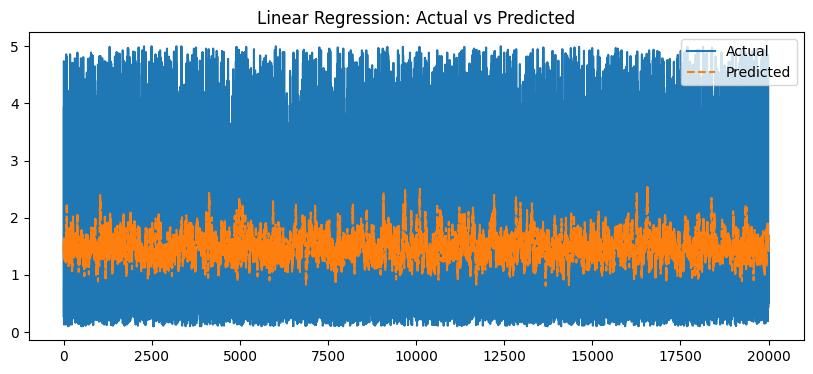

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted", linestyle="--")
plt.legend()
plt.title("Linear Regression: Actual vs Predicted")
plt.show()
